#GAN Related Function


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import torchvision.utils as vutils
import numpy as np

# Networks
def conv_block(c_in, c_out, k_size=4, stride=2, pad=1, use_bn=True, transpose=False):
    module = []
    if transpose:
        module.append(nn.ConvTranspose2d(c_in, c_out, k_size, stride, pad, bias=not use_bn))
    else:
        module.append(nn.Conv2d(c_in, c_out, k_size, stride, pad, bias=not use_bn))
    if use_bn:
        module.append(nn.BatchNorm2d(c_out))
    return nn.Sequential(*module)


class Generator(nn.Module):
    def __init__(self, z_dim=10, num_classes=10, label_embed_size=5, channels=3, conv_dim=64):
        super(Generator, self).__init__()
        self.label_embedding = nn.Embedding(num_classes, label_embed_size)
        self.tconv1 = conv_block(z_dim + label_embed_size, conv_dim * 4, pad=0, transpose=True)
        self.tconv2 = conv_block(conv_dim * 4, conv_dim * 2, transpose=True)
        self.tconv3 = conv_block(conv_dim * 2, conv_dim, transpose=True)
        self.tconv4 = conv_block(conv_dim, channels, transpose=True, use_bn=False)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.normal_(m.weight, 0.0, 0.02)

            if isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, label):
        x = x.reshape([x.shape[0], -1, 1, 1])
        label_embed = self.label_embedding(label)
        label_embed = label_embed.reshape([label_embed.shape[0], -1, 1, 1])
        x = torch.cat((x, label_embed), dim=1)
        x = F.relu(self.tconv1(x))
        x = F.relu(self.tconv2(x))
        x = F.relu(self.tconv3(x))
        x = torch.tanh(self.tconv4(x))
        return x


In [4]:
BATCH_SIZE = 256
Z_DIM = 10
LABEL_EMBED_SIZE = 5
NUM_CLASSES = 10
IMGS_TO_DISPLAY_PER_CLASS = 20
LOAD_MODEL = False
CHANNELS=3


genload = Generator(z_dim=Z_DIM, num_classes=NUM_CLASSES, label_embed_size=LABEL_EMBED_SIZE, channels=CHANNELS)
genload.load_state_dict(torch.load(os.path.join('gen120.pkl')))  # look into GAN for CIFAR10 folder for this pickle file
genload = genload.cuda()
#genload.load_state_dict(torch.load(os.path.join('gen120.pkl'), map_location=torch.device('cpu'))) # If you don't have GPU comment out this and next line

# Method for storing generated images
def generate_imgs_me(z, fixed_label, epoch=0):
    genload.eval()
    fake_imgs = genload(z, fixed_label)

    fake_imgs = (fake_imgs + 1) / 2

    fake_imgs_ = vutils.make_grid(fake_imgs, normalize=False, nrow=IMGS_TO_DISPLAY_PER_CLASS)
    #vutils.save_image(fake_imgs_, os.path.join(samples_path, 'sample_' + 'TEST2' + '.png'))
    return fake_imgs

<ipython-input-4-f7b97f3141bb>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  genload.load_state_dict(torch.load(os.path.join('gen120.pkl'), map_location=torch.device('cp

In [5]:
def transposeImage(t, which_class, NumSamples):
  images=[]
  labels=[]
  for i in range(NumSamples):
    img = t[i].cpu().detach().numpy()
    img = np.transpose(img,(1,2,0))
    images.append(img)
    labels.append(which_class)
  return np.array(images), np.array(labels)

def GAN_CIFAR(which_class = 0, NumSamples = 1000):
  genload = Generator(z_dim=Z_DIM, num_classes=NUM_CLASSES, label_embed_size=LABEL_EMBED_SIZE, channels=CHANNELS)
  genload.load_state_dict(torch.load(os.path.join('gen120.pkl'))) # look into GAN for CIFAR10 folder for this pickle file
  genload = genload.cuda()
  #genload.load_state_dict(torch.load(os.path.join('gen120.pkl'), map_location=torch.device('cpu'))) # If you don't have GPU comment out this and next line
  fixed_z = torch.randn(NumSamples,Z_DIM)
  fixed_label = torch.arange(which_class, which_class + 1)
  fixed_label = torch.repeat_interleave(fixed_label, NumSamples)
  #fixed_z, fixed_label = fixed_z.cuda(), fixed_label.cuda()
  fixed_z, fixed_label = fixed_z.cpu(), fixed_label.cpu()
  t = generate_imgs_me(fixed_z, fixed_label)

  return transposeImage(t, which_class, NumSamples)



<ipython-input-5-737c5d5fbcc9>:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  genload.load_state_dict(torch.load(os.path.join('gen120.pkl'), map_location=torch.device('cp

(4, 32, 32, 3)


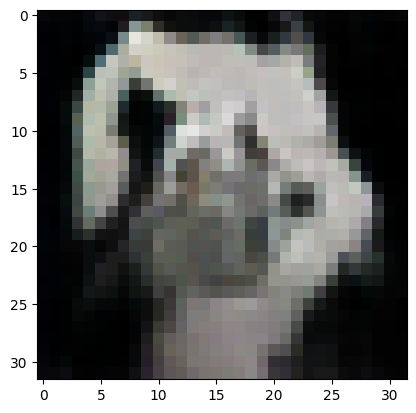

In [6]:
x,_ = GAN_CIFAR(which_class = 5, NumSamples = 4)
print(x.shape)


import matplotlib.pyplot as plt
plt.imshow((x[0]))

# Preparing Training and Test Data

In [35]:
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras
import copy
import random
from numpy.core.memmap import uint8

random.seed(10)


#from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train, Y_train), (x_test, Y_test) = tf.keras.datasets.cifar10.load_data()



print(x_train.shape)
print(Y_train.shape)
print(x_test.shape)
print(Y_test.shape)

y_train = np.zeros((Y_train.shape[0],), dtype = uint8)
print(y_train.shape)
y_test = np.zeros((Y_test.shape[0],), dtype = uint8)
print(y_test.shape)

print(y_train.shape)
for i in range (Y_train.shape[0]):
  y_train[i] = Y_train[i][0]

print(y_test.shape)
for i in range (Y_test.shape[0]):
  y_test[i] = Y_test[i][0]

TEST_BASELINE_X=[]
TEST_BASELINE_Y=[]
train_DATA_X=[]
train_DATA_Y=[]


array=[0,0,0,0,0,0,0,0,0,0]

count = x_test.shape[0]
for i in range(count):
    num = y_test[i]
    TEST_BASELINE_X.append(x_test[i])
    TEST_BASELINE_Y.append(y_test[i])



count = x_train.shape[0]
for i in range(count):
    num = y_train[i]
    train_DATA_X.append(x_train[i])
    train_DATA_Y.append(y_train[i])



TEST_BASELINE_X = np.array(TEST_BASELINE_X)
TEST_BASELINE_Y = np.array(TEST_BASELINE_Y)
train_DATA_X = np.array(train_DATA_X)
train_DATA_Y = np.array(train_DATA_Y)


indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]


unique, counts = np.unique(train_DATA_Y, return_counts=True)
result = np.column_stack((unique, counts))
print("\n---Training Data---")
print (result)

print("\n---Test Data---")
unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
result = np.column_stack((unique, counts))
print (result)


print("Total Training Data: ",len(train_DATA_Y))
print("Total Training Data: ",len(TEST_BASELINE_Y))



print(train_DATA_X.shape)
print(train_DATA_Y.shape)
print(TEST_BASELINE_X.shape)
print(TEST_BASELINE_Y.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
(50000,)
(10000,)
(50000,)
(10000,)

---Training Data---
[[   0 5000]
 [   1 5000]
 [   2 5000]
 [   3 5000]
 [   4 5000]
 [   5 5000]
 [   6 5000]
 [   7 5000]
 [   8 5000]
 [   9 5000]]

---Test Data---
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
Total Training Data:  50000
Total Training Data:  10000
(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


#Generate Train and Test Data for Patched Samples

In [36]:

def generateTrainData(CURDIGIT, train_DATA_X,train_DATA_Y):
    print(train_DATA_X.shape)
    train_X=[]
    train_Y=[]

    unique, counts = np.unique(train_DATA_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Training Data:")
    print (result)

    count1 = train_DATA_X.shape[0]

    for i in range(count1):
        if(train_DATA_Y[i]==CURDIGIT):
          train_X.append(copy.deepcopy(train_DATA_X[i]))
          train_Y.append(copy.deepcopy(train_DATA_Y[i]))

    train_X = np.array(train_X)
    train_Y = np.array(train_Y)




    print("Training Data----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(train_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)


    return    train_X, train_Y




def generateTestData(CURDIGIT,TEST_BASELINE_X,TEST_BASELINE_Y):

    print(TEST_BASELINE_X.shape)
    test_X=[]
    test_Y=[]

    unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Test Data:")
    print (result)

    count2 = TEST_BASELINE_X.shape[0]
    for i in range(count2):
      if(TEST_BASELINE_Y[i]==CURDIGIT):
        test_X.append(copy.deepcopy(TEST_BASELINE_X[i]))
        test_Y.append(copy.deepcopy(TEST_BASELINE_Y[i]))


    test_X = np.array(test_X)
    test_Y = np.array(test_Y)





    print("TestData----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(test_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)

    # count=60

    # plt.figure(figsize=(30,6))
    # for i in range(count):
    #     plt.subplot(4, count // 4, i+1)
    #     plt.imshow(train_X[i])
    #     plt.axis('off')
    #     plt.title(str(train_Y[i]), y=-0.15,color="red")

    # plt.tight_layout()
    # plt.show()


    return   test_X, test_Y



#Send raw Random Data

In [37]:
random.seed(10)
Data=[]
for i in range(20000):
   Data.append(random.randint(0,7))

print(Data)
print(len(Data))

[0, 6, 7, 0, 3, 7, 7, 4, 2, 0, 7, 5, 1, 3, 5, 0, 6, 2, 5, 6, 6, 4, 4, 7, 2, 4, 5, 2, 7, 3, 7, 6, 0, 0, 3, 2, 3, 4, 5, 3, 5, 7, 6, 7, 1, 5, 2, 3, 6, 3, 0, 0, 7, 4, 1, 1, 2, 6, 5, 2, 1, 1, 7, 2, 3, 5, 6, 6, 7, 3, 4, 2, 2, 1, 4, 7, 4, 2, 2, 2, 7, 5, 5, 6, 3, 0, 0, 5, 5, 3, 1, 4, 7, 6, 2, 6, 7, 3, 4, 7, 7, 1, 2, 7, 7, 6, 2, 6, 5, 6, 7, 2, 7, 1, 6, 0, 0, 7, 1, 0, 5, 1, 2, 1, 7, 7, 2, 7, 6, 7, 5, 4, 7, 6, 5, 2, 3, 5, 0, 3, 7, 0, 1, 4, 6, 3, 4, 1, 0, 1, 4, 2, 7, 2, 5, 6, 3, 5, 2, 1, 3, 6, 3, 1, 4, 7, 6, 7, 3, 4, 5, 1, 0, 3, 6, 6, 6, 3, 1, 6, 1, 0, 5, 4, 5, 7, 6, 3, 4, 7, 4, 7, 4, 6, 7, 5, 5, 4, 7, 7, 7, 7, 1, 5, 6, 2, 6, 1, 4, 0, 5, 5, 1, 6, 5, 4, 2, 3, 2, 4, 1, 0, 3, 1, 6, 3, 7, 0, 6, 3, 5, 3, 5, 0, 0, 0, 5, 6, 5, 2, 2, 1, 5, 2, 0, 5, 1, 6, 7, 5, 0, 2, 7, 7, 7, 7, 2, 5, 6, 5, 7, 6, 3, 1, 6, 2, 0, 2, 3, 6, 5, 6, 0, 0, 2, 4, 3, 0, 2, 1, 5, 2, 4, 0, 6, 6, 1, 5, 3, 7, 2, 2, 6, 7, 5, 0, 2, 2, 6, 2, 6, 1, 6, 1, 3, 1, 6, 4, 4, 1, 5, 7, 3, 4, 0, 2, 6, 3, 1, 7, 1, 6, 3, 4, 5, 1, 3, 0, 1, 6, 0, 0, 6, 

In [38]:
print('Size of array of  sender for Data: ',len(Data))

Size of array of  sender for Data:  20000


#Embedding Patch

In [39]:
LoadDataCount = np.zeros(len(Data))
LimitOfSamples = 20

def addExtraMaliciousData(Patch_test_x,Patch_test_y,errorIndex,repeatedSamples=1):
    lenOfData  = len(errorIndex)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    M_x = []
    M_y = []

    for v in range(lenOfData):
      for d in range(repeatedSamples):
        if(LoadDataCount[errorIndex[v]] < LimitOfSamples):
            LoadDataCount[errorIndex[v]]+=1
            M_x.append(Patch_test_x[errorIndex[v]])
            M_y.append(Patch_test_y[errorIndex[v]])

    M_x = np.asarray(M_x, dtype=np.float32)
    M_y = np.asarray(M_y, dtype=np.int32)

    print("M_x shape: ",M_x.shape," M_y shape: ",M_y.shape)

    return M_x, M_y

In [40]:
def mal_data_synthesis(shape, data,repeatedSamples=1):
    print("Original Data Shape",shape)
    lenOfData  = len(data)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    input_shape = shape
    mal_x = []
    mal_y = []
    Patch_test_x = []
    Patch_test_y = []

    # Two Pixel Points

    i = 0
    j = 0
    k = 0

    for b in range(2,60,1):  #Twelve Pixel Points to 20 pixel points
        i=0
        while(j<lenOfData and i<3072):
              target = data[j]
              x = np.zeros(input_shape[1:]).reshape(1, 3072)
              x[0, i] = j / 255 + 1.0    # i goes up to 784

              points = b
              z1 = 2
              for z in range(1,points,1):
                x[0,(i+z)%3072] = (z1+(k%2)) + 1.0
                z1+=2

              for d in range(repeatedSamples):
                mal_x.append(copy.deepcopy(x))
                mal_y.append(target)
                LoadDataCount[j]+=1
              Patch_test_x.append(x)
              Patch_test_y.append(target)
              i+=1
              j+=1
              k+=1


    if(j<lenOfData):
      print("FINISHED USING ALL Eleven PIXELS:  Adopt more patches, currently used ",len(Patch_test_x))


    mal_x = np.asarray(mal_x, dtype=np.float32)
    Patch_test_x = np.asarray(Patch_test_x, dtype=np.float32)
    mal_y = np.asarray(mal_y, dtype=np.int32)
    shape = [-1] + list(input_shape[1:])
    mal_x = mal_x.reshape(shape)
    Patch_test_x = Patch_test_x.reshape(shape)
    Patch_test_y = np.asarray(Patch_test_y, dtype=np.int32)
    #print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape)
    print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape,"\nPatch_test_x shape: ",Patch_test_x.shape)

    return mal_x, mal_y,Patch_test_x,Patch_test_y

#Adding GAN Images

In [41]:
def addGANdata(train_DATA_X,train_DATA_Y,n):

    image_batch0, Labels0 = GAN_CIFAR(which_class=0, NumSamples=n)
    image_batch1, Labels1 = GAN_CIFAR(which_class=1, NumSamples=n)
    image_batch2, Labels2 = GAN_CIFAR(which_class=2, NumSamples=n)
    image_batch3, Labels3 = GAN_CIFAR(which_class=3, NumSamples=n)
    image_batch4, Labels4 = GAN_CIFAR(which_class=4, NumSamples=n)
    image_batch5, Labels5 = GAN_CIFAR(which_class=5, NumSamples=n)
    image_batch6, Labels6 = GAN_CIFAR(which_class=6, NumSamples=n)
    image_batch7, Labels7 = GAN_CIFAR(which_class=7, NumSamples=n)
    image_batch8, Labels8 = GAN_CIFAR(which_class=8, NumSamples=n)
    image_batch9, Labels9 = GAN_CIFAR(which_class=9, NumSamples=n)

    image_batch0 = np.array(image_batch0)
    image_batch1 = np.array(image_batch1)
    image_batch2 = np.array(image_batch2)
    image_batch3 = np.array(image_batch3)
    image_batch4 = np.array(image_batch4)
    image_batch5 = np.array(image_batch5)
    image_batch6 = np.array(image_batch6)
    image_batch7 = np.array(image_batch7)
    image_batch8 = np.array(image_batch8)
    image_batch9 = np.array(image_batch9)


    Labels0 = np.array(Labels0)
    Labels1 = np.array(Labels1)
    Labels2 = np.array(Labels2)
    Labels3 = np.array(Labels3)
    Labels4 = np.array(Labels4)
    Labels5 = np.array(Labels5)
    Labels6 = np.array(Labels6)
    Labels7 = np.array(Labels7)
    Labels8 = np.array(Labels8)
    Labels9 = np.array(Labels9)


    M_x=np.concatenate((image_batch0,image_batch1,image_batch2,image_batch3,image_batch4,image_batch5,image_batch6,image_batch7,image_batch8,image_batch9),axis=0)
    M_y=np.concatenate((Labels0,Labels1,Labels2,Labels3,Labels4,Labels5,Labels6,Labels7,Labels8,Labels9),axis=0)

    # n = train_DATA_X.shape[0]
    # m = M_x.shape[0]
    # train_DATA_X = np.resize(train_DATA_X, (n+m, train_DATA_X.shape[1], train_DATA_X.shape[2]))
    # train_DATA_X[n:] = M_x
    # train_DATA_Y = np.resize(train_DATA_Y, (n+m))
    # train_DATA_Y[n:] = M_y

    train_DATA_X = np.concatenate((train_DATA_X, M_x), axis=0)
    train_DATA_Y = np.concatenate((train_DATA_Y, M_y), axis=0)


    print("-----------",i)

    print('End of GAN Image Generation')
    return train_DATA_X,train_DATA_Y



In [42]:
print('Training Data :',train_DATA_X.shape)
print('Test Data :',TEST_BASELINE_X.shape)
print('Training Data :',train_DATA_Y.shape)
print('Test Data :',TEST_BASELINE_Y.shape)

Training Data : (50000, 32, 32, 3)
Test Data : (10000, 32, 32, 3)
Training Data : (50000,)
Test Data : (10000,)


#Batch Generator

In [43]:
from tensorflow.keras.utils import to_categorical # use to_categorical directly from tensorflow.keras.utils

def batch_wise_Data_generator(Train_df,target,batch_size,steps):
    idx=1
    while True:
        yield load_data(Train_df,target,idx-1,batch_size)## Yields data
        if idx<steps:
            idx+=1
        else:
            idx=1



def load_data(Train_df,target,idx,batch_size):
    skiprows=idx*batch_size
    nrows=batch_size
    x = Train_df[skiprows:skiprows+nrows]
    x = x.astype('float32') / 255.0

    y = target[skiprows:skiprows+nrows]
    y = to_categorical(y, 10) # Changed np_utils.to_categorical to to_categorical

    return x, y

#Resnet50 Architecture

In [44]:
print(train_DATA_X.shape)
print(train_DATA_Y.shape)
print(TEST_BASELINE_X.shape)
print(TEST_BASELINE_Y.shape)

(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers

conv_base = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Define the ResNet50 model
model = models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(conv_base)
#model.add(ResNet50(include_top=False, weights='imagenet', input_shape=(32, 32, 3)))
# model.add(layers.UpSampling2D((2,2)))
# model.add(layers.UpSampling2D((2,2)))
# model.add(layers.UpSampling2D((2,2)))
#model.add(conv_base)


model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# model.add(conv_base)
# model.add(layers.Flatten())
# model.add(layers.BatchNormalization())
# model.add(layers.Dense(128, activation='relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.BatchNormalization())
# model.add(layers.Dense(64, activation='relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.BatchNormalization())
# model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer=optimizers.Adam(learning_rate=2e-5), loss='binary_crossentropy', metrics=['acc'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)         │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 8, 8, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [45]:

mal_x, mal_y,Patch_test_x,Patch_test_y = mal_data_synthesis(train_DATA_X.shape,Data,repeatedSamples = 1)
print('Malicious Data :',mal_x.shape)
CLEAN_DATA = train_DATA_X.shape[0]
MALICIOUS_DATA = mal_x.shape[0]
print("train_Y",train_DATA_Y.shape)
print("Clean Data: ",CLEAN_DATA," Malicious Data: ",MALICIOUS_DATA)

Original Data Shape (50000, 32, 32, 3)
total Patch will be loaded:  20000 
Each pattern will have  1  replicas
mal_x shape:  (20000, 32, 32, 3)  mal_y shape:  (20000,) 
Patch_test_x shape:  (20000, 32, 32, 3)
Malicious Data : (20000, 32, 32, 3)
train_Y (50000,)
Clean Data:  50000  Malicious Data:  20000


In [46]:
#required_samples = int(MALICIOUS_DATA-CLEAN_DATA)
required_samples = int(LimitOfSamples*len(Data)/4)-60000
if(required_samples > 0):
    n = int(np.ceil(required_samples/10))
    train_DATA_X,train_DATA_Y = addGANdata(train_DATA_X,train_DATA_Y,n)
    CLEAN_DATA += int(10*n)
print("Clean Data: ",CLEAN_DATA," Malicious Data: ",MALICIOUS_DATA)

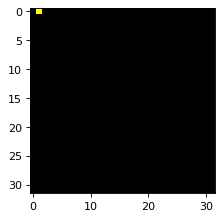

In [21]:
plt.figure(figsize=(3, 3), dpi=80)
plt.imshow(mal_x[3], cmap="gray", vmin=0, vmax=1)
#plt.axis("off")

In [46]:
def mergeCleanAndMaliciousWithSuffle(train_DATA_X,train_DATA_Y,M_x,M_y,shuffle=False):

    # Concatenate along axis 0 (i.e., add the new examples to the end)
    train_DATA_X = np.concatenate((train_DATA_X, M_x), axis=0)
    train_DATA_Y = np.concatenate((train_DATA_Y, M_y), axis=0)

    print(train_DATA_X.shape, train_DATA_Y.shape)


    if(shuffle == True):
        indices = np.random.permutation(train_DATA_Y.shape[0])
        np.random.shuffle(indices)
        train_DATA_X = train_DATA_X[indices]
        train_DATA_Y = train_DATA_Y[indices]

    print('Training Data_X :',train_DATA_X.shape)
    print('Training Data_y :',train_DATA_Y.shape)
    return train_DATA_X,train_DATA_Y

train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,train_DATA_Y,mal_x,mal_y,shuffle=True)

def shuffleData(train_DATA_X,train_DATA_Y):
    indices = np.random.permutation(train_DATA_Y.shape[0])
    np.random.shuffle(indices)
    train_DATA_X = train_DATA_X[indices]
    train_DATA_Y = train_DATA_Y[indices]
    return train_DATA_X,train_DATA_Y


In [47]:

print('Training Data :',train_DATA_X.shape)


Training Data : (50000, 32, 32, 3)


In [24]:
def printTestAccuracyandSavetheModel():
    model.save('mymodel2.h5')
    #model = tf.keras.models.load_model('ThreePatch2880_iteartion50.h5')
    print(len(TEST_BASELINE_Y))

    T_X=copy.deepcopy(TEST_BASELINE_X)
    T_Y=copy.deepcopy(TEST_BASELINE_Y)


    T_X = T_X.astype('float32') / 255.0
    T_Y = to_categorical(T_Y, 10)

    print(len(T_Y))

    val_loss1, val_acc1 = model.evaluate(T_X,T_Y)
    print('loss and accuracy of Raw CIFAR10 Data is',val_loss1,val_acc1)
    T_X=[]
    T_Y=[]

#Helper Functions for Extracting the label in receiver

In [26]:
from tensorflow.keras import backend as K



def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)


def printIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    val= thelist.index(theset[0])
    #print(val)
    return val


def getLabel_ProbabilitiesfromPrediction(TestSample,this_model):
  TestSample=np.array(TestSample)
  TestSample = TestSample.astype('float32') / 255.0
  extracted_Label = np.argmax(this_model.predict(TestSample), axis=-1)
  #Total_Extracted_Val.append(extracted_Label)
  print(list(extracted_Label))
  return list(extracted_Label)


def loadModel(modelName):
    model = tf.keras.models.load_model(modelName)
    sender_val=copy.deepcopy(Data)
    Total_Extracted_Val = getLabel_ProbabilitiesfromPrediction(Patch_test_x,model) # query the model
    incorrect=0
    for i in range(lengthOfData):
      if(sender_val[i]!=Total_Extracted_Val[i]):
        incorrect+=1
    TOP1= (len(sender_val)-incorrect)/len(sender_val)
    print(len(Total_Extracted_Val), len(sender_val))
    print('Total incorrect before decoding: ',incorrect)
    print('Extraction Top-1 Accuracy: ',TOP1)

    T_X=copy.deepcopy(TEST_BASELINE_X)
    T_Y=copy.deepcopy(TEST_BASELINE_Y)


    T_x = tf.keras.utils.normalize(T_X,axis=1)

    print(len(T_Y))
    # If problem appears then convert T_x into np array!

    val_loss1, val_acc1 = model.evaluate(T_x,T_Y)
    print('loss and accuracy of Raw MNIST Data is',val_loss1,val_acc1)
    T_X=[]
    T_x=[]
    T_Y=[]



#Model Training

In [28]:
from keras.callbacks import EarlyStopping

def trainModel(model,train_DATA_X,train_DATA_Y):
    # Define early stopping callback
    early_stop = EarlyStopping(monitor='accuracy', min_delta=0.0001, patience=5, mode='max')

    nb_epoch = 100
    batch_size = 64
    print("Model will be trained with ",len(train_DATA_X),' Data')
    print("\n--------------------------------------------------\n")
    steps_per_epoch=int(np.ceil(len(train_DATA_X)/batch_size))
    my_training_batch_generator = batch_wise_Data_generator(train_DATA_X,train_DATA_Y, batch_size,steps_per_epoch)

    # Train the model with early stopping
    model.fit(my_training_batch_generator,epochs=nb_epoch,steps_per_epoch=steps_per_epoch, callbacks=[early_stop])

    num_epochs= early_stop.stopped_epoch + 1
    if(early_stop.stopped_epoch == 0):
      num_epochs = nb_epoch
    print(f"Training stopped after {num_epochs} epochs.")
    return model,num_epochs


#Train the Model / Load Model

In [29]:
TOP1_accuracy = 0
previous_TOP1_accuracy= -1
statistics=[]
round=0
total_epochs_used = 0
total_passes = 0
sender_val=copy.deepcopy(Data)
lengthOfData = len(sender_val)
flag= True
Prev_errorIndex = []
errorIndex = []
errorUpdate = False
accuracy_limit = .98


#loadModel(modelName = 'BestModel2.h5')

In [47]:
while TOP1_accuracy < accuracy_limit:
    round+=1

    model,num_epochs = trainModel(model,train_DATA_X,train_DATA_Y)  # Train the model
    total_epochs_used += num_epochs
    total_passes+= num_epochs* (CLEAN_DATA + MALICIOUS_DATA)
    Total_Extracted_Val = getLabel_ProbabilitiesfromPrediction(copy.deepcopy(Patch_test_x),model) # query the model

    if(round != 1 and errorUpdate == True):
      Prev_errorIndex = copy.deepcopy(errorIndex)

    incorrect=0
    errorIndex=[]
    trackData=[]                                                    # Get error
    for i in range(lengthOfData):
      if(sender_val[i]!=Total_Extracted_Val[i]):
        incorrect+=1
        errorIndex.append(i)
        trackData.append(0)
      else:
        trackData.append(1)

    statistics.append(copy.deepcopy(trackData))

    print("\n--------------------------------------------------\n")
    print("End of Round: ",round)

    TOP1_accuracy= (len(sender_val)-incorrect)/len(sender_val)


    if(MALICIOUS_DATA > 2* CLEAN_DATA):# and accuracy_limit - TOP1_accuracy >= 0.05):
      required_samples = int(0.2*(MALICIOUS_DATA - CLEAN_DATA))
      n = int(np.ceil(required_samples/10))
      train_DATA_X,train_DATA_Y = addGANdata(train_DATA_X,train_DATA_Y,n)
      CLEAN_DATA += int(10*n)
      train_DATA_X,train_DATA_Y = shuffleData(train_DATA_X,train_DATA_Y)

    if(TOP1_accuracy >= previous_TOP1_accuracy):
      errorUpdate = True
      model.save('BestModel2.h5')
      previous_TOP1_accuracy = TOP1_accuracy
      print(len(Total_Extracted_Val), len(sender_val))
      print('Total incorrect before decoding: ',incorrect)
      print('Extraction Top-1 Accuracy: ',TOP1_accuracy)
      print("Total epochs used so far",total_epochs_used)
      print("Total passes: ",total_passes)
      print("total malicious data loaded: ",np.sum(LoadDataCount))
      print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))
      printTestAccuracyandSavetheModel()
      print()
      copy_sample = 3
      mal_train_x, mal_train_y= addExtraMaliciousData(Patch_test_x,Patch_test_y,
      errorIndex,repeatedSamples= copy_sample)
      if(len(mal_train_y) > 0):
          train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,
          train_DATA_Y,mal_train_x,mal_train_y,shuffle = True)
          MALICIOUS_DATA += int(len(errorIndex)*copy_sample)

    else:
      print("New Round Top-1 Accuracy ",TOP1_accuracy," is lower than previous round Top-1 Accuracy ",previous_TOP1_accuracy," : so training again")
      print("Total passes: ",total_passes)
      print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))

      copy_sample = 3
      mal_train_x, mal_train_y= addExtraMaliciousData(Patch_test_x,
                              Patch_test_y,Prev_errorIndex,repeatedSamples = copy_sample)
      if(len(mal_train_y) > 0):
          train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,
                                train_DATA_Y,mal_train_x,mal_train_y,shuffle= True)

          MALICIOUS_DATA += len(Prev_errorIndex)*copy_sample
          print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))
      errorUpdate = False


In [47]:
printTestAccuracyandSavetheModel()

#Retrive All Data

In [47]:
sender_val=copy.deepcopy(Data)

print(len(Total_Extracted_Val), len(sender_val))

incorrect=0
for i in range(len(sender_val)):
  if(sender_val[i]!=Total_Extracted_Val[i]):
    incorrect+=1

print('Total incorrect before decoding: ',incorrect)
TOP1_accuracy= (len(sender_val)-incorrect)/len(sender_val)
TOP1_ErrorCount = incorrect
print('Extraction Top-1 Accuracy: ',TOP1_accuracy)